**E-commerce Purchase Analysis**

**Objective**
The aim of this project is to analyze customer purchase behavior based on language, job, payment method, and purchase timing.

In [4]:
#from google.colab import files

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
data=pd.read_csv("ecom_purch.csv")
data

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
0,"16629 Pace Camp Apt. 448\r\nAlexisborough, NE ...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14
1,"9374 Jasmine Spurs Suite 508\r\nSouth John, TN...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
2,Unit 0065 Box 5052\r\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95
3,"7780 Julia Fords\r\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
4,"23012 Munoz Drive Suite 337\r\nNew Cynthia, TX...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,"966 Castaneda Locks\r\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21
9996,"832 Curtis Dam Suite 785\r\nNorth Edwardburgh,...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63
9997,Unit 4434 Box 6343\r\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98
9998,"0096 English Rest\r\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84


In [7]:
data.head(10)

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
0,"16629 Pace Camp Apt. 448\r\nAlexisborough, NE ...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14
1,"9374 Jasmine Spurs Suite 508\r\nSouth John, TN...",28 rn,PM,Opera/8.93.(Windows 98; Win 9x 4.90; en-US) Pr...,"Fletcher, Richards and Whitaker",3337758169645356,11/18,561,Mastercard,anthony41@reed.com,Drilling engineer,15.160.41.51,fr,70.73
2,Unit 0065 Box 5052\r\nDPO AP 27450,94 vE,PM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Simpson, Williams and Pham",675957666125,08/19,699,JCB 16 digit,amymiller@morales-harrison.com,Customer service manager,132.207.160.22,de,0.95
3,"7780 Julia Fords\r\nNew Stacy, WA 45798",36 vm,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_0 ...,"Williams, Marshall and Buchanan",6011578504430710,02/24,384,Discover,brent16@olson-robinson.info,Drilling engineer,30.250.74.19,es,78.04
4,"23012 Munoz Drive Suite 337\r\nNew Cynthia, TX...",20 IE,AM,Opera/9.58.(X11; Linux x86_64; it-IT) Presto/2...,"Brown, Watson and Andrews",6011456623207998,10/25,678,Diners Club / Carte Blanche,christopherwright@gmail.com,Fine artist,24.140.33.94,es,77.82
5,"7502 Powell Mission Apt. 768\r\nTravisland, VA...",21 XT,PM,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_8_5...,Silva-Anderson,30246185196287,07/25,7169,Discover,ynguyen@gmail.com,Fish farm manager,55.96.152.147,ru,25.15
6,"93971 Conway Causeway\r\nAndersonburgh, AZ 75107",96 Xt,AM,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...,Gibson and Sons,6011398782655569,07/24,714,VISA 16 digit,olivia04@yahoo.com,Dancer,127.252.144.18,de,88.56
7,"260 Rachel Plains Suite 366\r\nCastroberg, WV ...",96 pG,PM,Mozilla/5.0 (X11; Linux i686) AppleWebKit/5350...,Marshall-Collins,561252141909,06/25,256,VISA 13 digit,phillip48@parks.info,Event organiser,224.247.97.150,pt,44.25
8,"2129 Dylan Burg\r\nNew Michelle, ME 28650",45 JN,PM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Galloway and Sons,180041795790001,04/24,899,JCB 16 digit,kdavis@rasmussen.com,Financial manager,146.234.201.229,ru,59.54
9,"3795 Dawson Extensions\r\nLake Tinafort, ID 88739",15 Ug,AM,Mozilla/5.0 (X11; Linux i686; rv:1.9.7.20) Gec...,"Rivera, Buchanan and Ramirez",4396283918371,01/17,931,American Express,qcoleman@hunt-huerta.com,Forensic scientist,236.198.199.8,zh,95.63


In [8]:
df_analysis = data[['Address', 'AM or PM', 'Company', 'Credit Card',
       'CC Exp Date', 'CC Security Code', 'CC Provider', 'Email', 'Job',
       'IP Address', 'Language', 'Purchase Price']]

In [9]:
data.tail(5)

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price
9995,"966 Castaneda Locks\r\nWest Juliafurt, CO 96415",92 XI,PM,Mozilla/5.0 (Windows NT 5.1) AppleWebKit/5352 ...,Randall-Sloan,342945015358701,03/22,838,JCB 15 digit,iscott@wade-garner.com,Printmaker,29.73.197.114,it,82.21
9996,"832 Curtis Dam Suite 785\r\nNorth Edwardburgh,...",41 JY,AM,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,"Hale, Collins and Wilson",210033169205009,07/25,207,JCB 16 digit,mary85@hotmail.com,Energy engineer,121.133.168.51,pt,25.63
9997,Unit 4434 Box 6343\r\nDPO AE 28026-0283,74 Zh,AM,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_7...,Anderson Ltd,6011539787356311,05/21,1,VISA 16 digit,tyler16@gmail.com,Veterinary surgeon,156.210.0.254,el,83.98
9998,"0096 English Rest\r\nRoystad, IA 12457",74 cL,PM,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_8;...,Cook Inc,180003348082930,11/17,987,American Express,elizabethmoore@reid.net,Local government officer,55.78.26.143,es,38.84
9999,"40674 Barrett Stravenue\r\nGrimesville, WI 79682",64 Hr,AM,Mozilla/5.0 (X11; Linux i686; rv:1.9.5.20) Gec...,Greene Inc,4139972901927273,02/19,302,JCB 15 digit,rachelford@vaughn.com,"Embryologist, clinical",176.119.198.199,el,67.59


##  Data Overview
-The dataset contains information about customer jobs, language,purchase price, credit card provider, and purchase time.

-There are no missing values in the dataset.


In [10]:
data.dtypes

Address                 str
Lot                     str
AM or PM                str
Browser Info            str
Company                 str
Credit Card           int64
CC Exp Date             str
CC Security Code      int64
CC Provider             str
Email                   str
Job                     str
IP Address              str
Language                str
Purchase Price      float64
dtype: object

In [11]:
data.isnull().sum()

Address             0
Lot                 0
AM or PM            0
Browser Info        0
Company             0
Credit Card         0
CC Exp Date         0
CC Security Code    0
CC Provider         0
Email               0
Job                 0
IP Address          0
Language            0
Purchase Price      0
dtype: int64

In [12]:
len(data.columns)

14

In [13]:
len(data)

10000

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Address           10000 non-null  str    
 1   Lot               10000 non-null  str    
 2   AM or PM          10000 non-null  str    
 3   Browser Info      10000 non-null  str    
 4   Company           10000 non-null  str    
 5   Credit Card       10000 non-null  int64  
 6   CC Exp Date       10000 non-null  str    
 7   CC Security Code  10000 non-null  int64  
 8   CC Provider       10000 non-null  str    
 9   Email             10000 non-null  str    
 10  Job               10000 non-null  str    
 11  IP Address        10000 non-null  str    
 12  Language          10000 non-null  str    
 13  Purchase Price    10000 non-null  float64
dtypes: float64(1), int64(2), str(11)
memory usage: 1.1 MB


In [15]:
#highest and lowest purchase prices
data['Purchase Price'].max()

np.float64(99.99)

In [16]:
data['Purchase Price'].min()

np.float64(0.0)

In [17]:
data['Purchase Price'].mean()

np.float64(50.347302)

**Interpretation**

- The maximum purchase price is relatively high, indicating the presence of premium customers.

- The average purchase price suggests moderate spending behavior.

In [18]:
#how many people have french fr as their language
len(data[data['Language']=='fr'])

1097

In [19]:
data[data['Language']=='fr'].count()

Address             1097
Lot                 1097
AM or PM            1097
Browser Info        1097
Company             1097
Credit Card         1097
CC Exp Date         1097
CC Security Code    1097
CC Provider         1097
Email               1097
Job                 1097
IP Address          1097
Language            1097
Purchase Price      1097
dtype: int64

In [20]:
len(data[data['Job'].str.contains('engineer',case=False)])


984

In [21]:
data[data['IP Address']=='132.207.160.22']['Email']

2    amymiller@morales-harrison.com
Name: Email, dtype: str

In [22]:
#how many people have mastercard as their credit card provider and made a purchase above 50

len(data[(data['CC Provider']=="Mastercard")&(data['Purchase Price']>50)])

405

In [23]:
data[data['Credit Card']==4664825258997302]['Email']

9992    bberry@wright.net
Name: Email, dtype: str

In [24]:
#how many people purchase during the AM and how many people purchase during PM
data['AM or PM'].value_counts()

AM or PM
PM    5068
AM    4932
Name: count, dtype: int64

**Time-Based Purchase Behavior**

In [25]:
#how many people have a credit card that expires in 2020

data['CC Exp Date']

0       02/20
1       11/18
2       08/19
3       02/24
4       10/25
        ...  
9995    03/22
9996    07/25
9997    05/21
9998    11/17
9999    02/19
Name: CC Exp Date, Length: 10000, dtype: str

In [26]:
def fun():
  count=0
  for date in data['CC Exp Date']:
    if date.split('/')[1]=='20':
      count=count+1
  print(count)

In [27]:
fun()

988


In [28]:
mastercard_high=data[data['CC Exp Date'].apply(lambda x:x[3:]=='20')]
len(mastercard_high)

988

In [29]:
#top 5 most popular email providers(eg.gmail.com,yahoo.com,etc...)

list1=[]
for email in data['Email']:
  list1.append(email.split('@')[1])

In [30]:
data['temp']=list1

In [31]:
data.head(1)

,Address,Lot,AM or PM,Browser Info,Company,Credit Card,CC Exp Date,CC Security Code,CC Provider,Email,Job,IP Address,Language,Purchase Price,temp
0,"16629 Pace Camp Apt. 448\r\nAlexisborough, NE ...",46 in,PM,Opera/9.56.(X11; Linux x86_64; sl-SI) Presto/2...,Martinez-Herman,6011929061123406,02/20,900,JCB 16 digit,pdunlap@yahoo.com,"Scientist, product/process development",149.146.147.205,el,98.14,yahoo.com


In [32]:
data['temp'].value_counts().head()

temp
hotmail.com     1638
yahoo.com       1616
gmail.com       1605
smith.com         42
williams.com      37
Name: count, dtype: int64

**Purchase Price distribution**

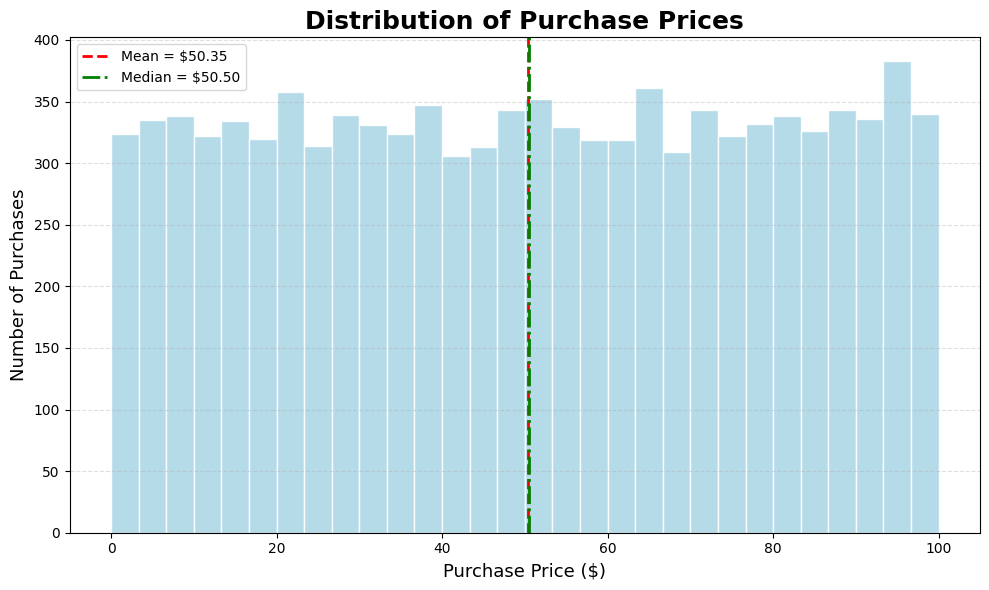

In [46]:
mean_price = data["Purchase Price"].mean()
median_price = data["Purchase Price"].median()

plt.figure(figsize=(10,6))

plt.hist(data["Purchase Price"],
    bins=30,
    color="lightblue",
    edgecolor="white",
    linewidth=1,
    alpha=0.9)

plt.axvline(mean_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = ${mean_price:.2f}")

plt.axvline(median_price,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median = ${median_price:.2f}")

plt.title("Distribution of Purchase Prices",
    fontsize=18,
    fontweight="bold")

plt.xlabel("Purchase Price ($)", fontsize=13)
plt.ylabel("Number of Purchases", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()

**AM vs PM**

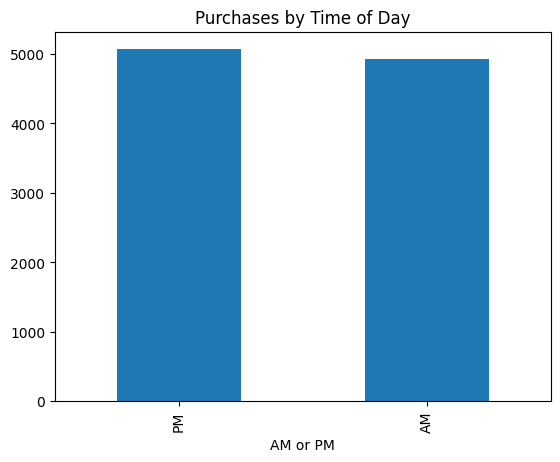

In [35]:
data['AM or PM'].value_counts().plot(kind='bar')
plt.title("Purchases by Time of Day")
plt.show()


- Most purchases occur during the PM.

In [36]:
data['AM_PM_Code'] = data['AM or PM'].map({'AM': 0, 'PM': 1})
data['Expiry Date'] = data['CC Exp Date'].astype(str)


In [37]:
#top expiry dates in AM purchases
data['Expiry_Year'] = data['Expiry Date'].str.split('/').str[1]
expiry_am_pm_year = (
    data.groupby(['AM or PM', 'Expiry_Year'])
      .size()
      .reset_index(name='Count')
)



**Customer Segmentation**


**Segment customers by spending behavior**


In [38]:
data['Spending_Category'] = pd.cut(
    data['Purchase Price'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Premium'])
data['Spending_Category'].value_counts()


Spending_Category
Premium    2564
High       2488
Low        2475
Medium     2471
Name: count, dtype: int64

**Interpretation**

The nearly equal distribution across spending categories indicates that the platform successfully attracts customers across all spending levels. This reduces dependency on a single customer segment and provides stability in revenue generation.

**Revenus Contribution Analysis**

-Which group contributes MOST revenue?

In [39]:
job_revenue = data.groupby('Job')['Purchase Price'].sum().sort_values(ascending=False)
job_revenue.head(10)


Job
Dietitian                            1605.30
Lawyer                               1603.85
Purchasing manager                   1577.97
Therapist, art                       1526.31
Clinical cytogeneticist              1495.92
Research officer, political party    1488.79
Designer, jewellery                  1482.20
Interior and spatial designer        1466.20
Network engineer                     1421.73
Social researcher                    1416.34
Name: Purchase Price, dtype: float64

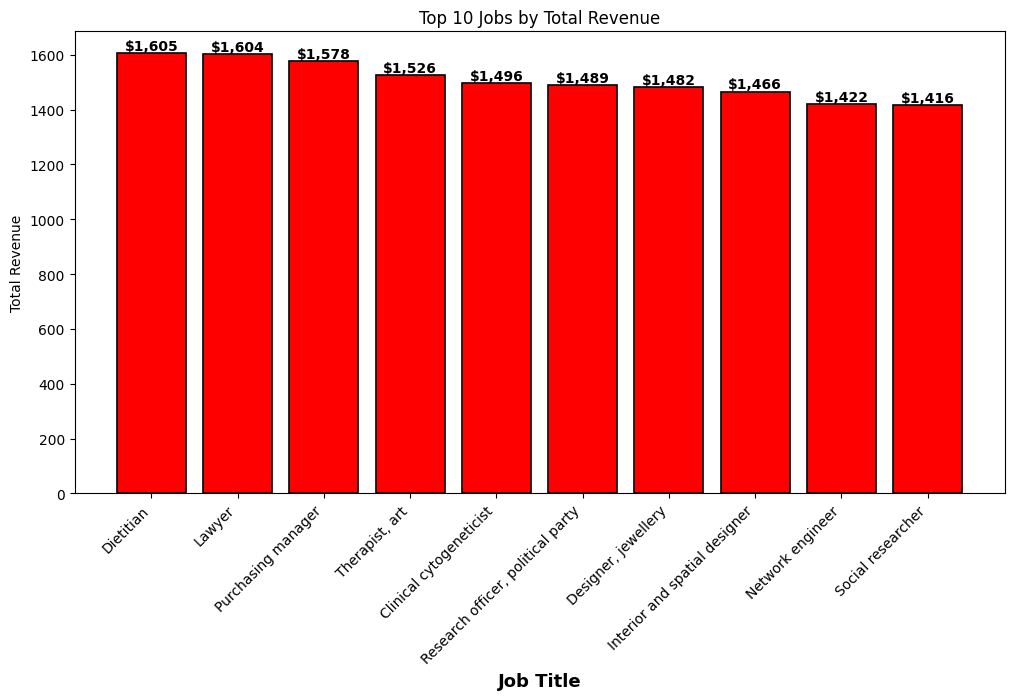

In [56]:
top_jobs = job_revenue.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(top_jobs.index,
    top_jobs.values,
    color="red",
    edgecolor="black",
    linewidth=1.2)

plt.xlabel("Job Title",
    fontsize=13,
    fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold")
        
plt.title("Top 10 Jobs by Total Revenue")
plt.ylabel("Total Revenue")
plt.show()


**Interpretation**
-  The results show that Dietitians and Lawyers are the highest revenue-contributing job groups, each generating purchase values exceeding 1600 units. This suggests that customers in these professions either exhibit higher purchasing power
.


In [41]:
cc_analysis = data.groupby('CC Provider').agg(
    Avg_Purchase=('Purchase Price','mean'),
    Total_Revenue=('Purchase Price','sum'),
    Transactions=('Purchase Price','count')
)
cc_analysis.sort_values(by='Total_Revenue', ascending=False)


,Avg_Purchase,Total_Revenue,Transactions
CC Provider,,,
VISA 16 digit,49.871055,85528.86,1715
JCB 16 digit,49.299143,84597.33,1716
JCB 15 digit,51.125115,44376.60,868
Voyager,51.973185,43085.77,829
American Express,50.489423,42865.52,849
Maestro,50.379173,42620.78,846
Discover,51.662338,42208.13,817
Mastercard,50.043015,40835.10,816
VISA 13 digit,51.449858,39976.54,777


**Interpretation**
- The results indicate that VISA (16-digit) and JCB (16-digit) cards generate the highest total revenue, each contributing over 84,000 units.

- This high revenue is primarily driven by their large transaction volumes, rather than exceptionally high average purchase values.


**Language vs Spending Behavior**


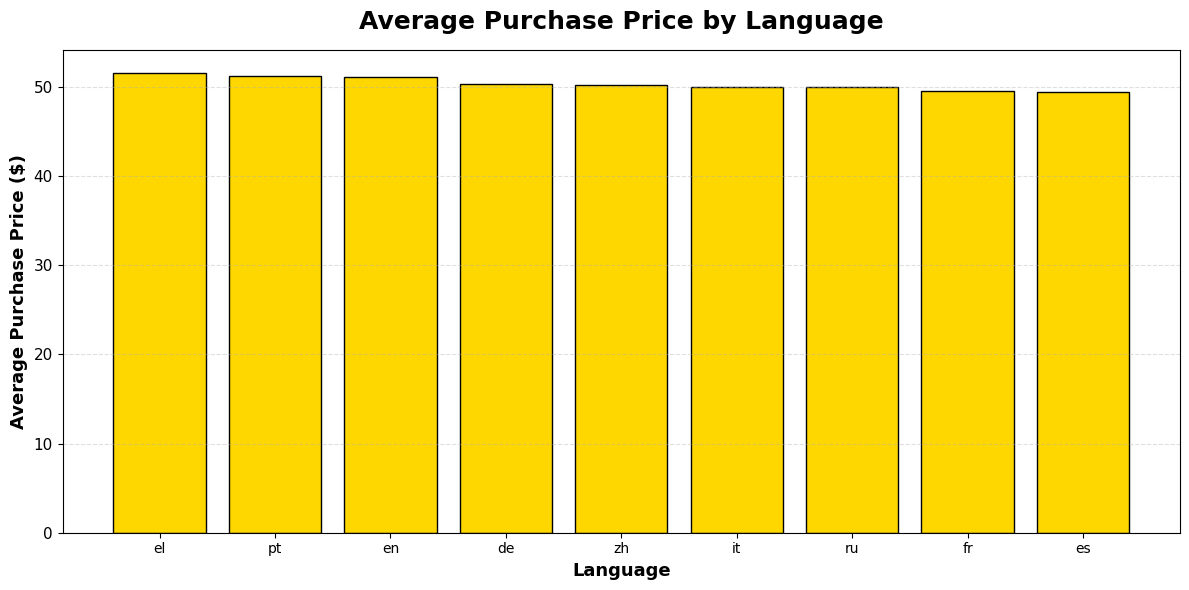

In [58]:
language_avg = data.groupby('Language')['Purchase Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))

bars = plt.bar(language_avg.index,
    language_avg.values,
    color="gold",
    edgecolor="black",
    linewidth=1)

plt.title("Average Purchase Price by Language",
    fontsize=18,
    fontweight="bold",
    pad=15)

plt.xlabel("Language",
    fontsize=13,
    fontweight="bold")

plt.ylabel("Average Purchase Price ($)",
    fontsize=13,
    fontweight="bold")
plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



- The analysis compares the mean purchase price across different language groups.
- This uniformity suggests that language preference does not significantly influence per-transaction spending behavior within the dataset.
